# 02 – Data Understanding

**Project:** Diabetes Prediction ML  
**Seminar:** Advanced Applied Data Science – Goethe University Frankfurt  
**Dataset:** CDC BRFSS 2015 – Diabetes Health Indicators (UCI #891)  
**Target:** `Diabetes_binary` (0 = No Diabetes, 1 = Prediabetes/Diabetes)  
**CRISP-DM phase:** 2 – Data Understanding

---

## Purpose of this notebook

Having defined *what* we predict and *how* success is measured (NB01), we now examine the data itself: structure, quality, distributions, and feature–target relationships. This is **descriptive EDA on the full dataset, before the train/test split (NB03)**; the methodological scope (no leakage into the fitted pipeline) is set out in §1.2. The findings inform feature selection, encoding, and the data-preparation steps in the following notebooks.

## 1. Setup

Install the UCI ML Repository client if it is not yet available, then import all required libraries. This notebook contains no stochastic steps, so its results are deterministic; a fixed plotting style keeps figures identical across machines.

In [1]:
# Install ucimlrepo if running in a fresh environment
import importlib.util, subprocess, sys
if importlib.util.find_spec('ucimlrepo') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ucimlrepo'])

# Suppress only forward-looking deprecation warnings (real warnings stay visible)
import warnings
warnings.simplefilter("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker   # thousands-formatting of plot axes
import seaborn as sns                 # heatmap (§8) + global plot style
from scipy import stats               # Spearman rank correlation (§8)
from ucimlrepo import fetch_ucirepo   # loads UCI dataset #891 (§1.1)

# Deterministic, machine-independent plotting style (no stochastic steps in this notebook)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')

# Output directory for figures (relative path → reproducible on any machine, created automatically)
from pathlib import Path
OUTPUT_DIR = Path("outputs") / "nb02"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### 1.1 Loading the dataset

The dataset is loaded directly from the UCI ML Repository via its official ID (891). This guarantees reproducibility without relying on a local CSV file or any local path.

In [2]:
# Fetch dataset from UCI ML Repository
dataset = fetch_ucirepo(id=891)

X = dataset.data.features
y = dataset.data.targets

# Combine into a single DataFrame for convenience
df = pd.concat([X, y], axis=1)

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded: 253,680 rows × 22 columns


The dataset loads as expected: **253,680 rows × 22 columns** (21 features + the `Diabetes_binary` target), matching the documented UCI #891 dimensions. No local file is involved, so the load is fully reproducible on any machine with internet access.

### 1.2 Methodological note — scope of this notebook

This notebook is **descriptive exploratory analysis on the full dataset** (CRISP-DM *Data Understanding*), carried out *before* the train/test split in NB03. To keep the later evaluation unbiased, two rules hold throughout:

- **No statistic computed here is reused as a fitted parameter.** All model-affecting transformations — scaling, BMI capping thresholds, encoders, SMOTE, feature selection — are fit **train-only / per CV-fold** in NB03/05/06, never on the full data.
- **The target-conditioned summaries (Sections 7–9) are exploratory only.** They motivate hypotheses and *plans* for data preparation; any concrete cut-point shown (e.g. the P1/P99 BMI bounds) is **re-derived on the training split** in NB03, so the values here are indicative, not the parameters that enter the model.

This is what keeps EDA-before-split legitimate: we inspect the whole dataset to understand it, but no number leaks from here into the fitted pipeline.

## 2. Basic Structure

Before any content analysis, we get an overview of dimensions, data types and missing values — the three most fundamental quality questions for any new dataset.

In [3]:
# --- Dimensions ---
n_rows, n_cols = df.shape
print(f"Rows   : {n_rows:,}")
print(f"Columns: {n_cols}  (21 features + 1 target)\n")

# --- Features & data types ---
dtype_map   = df.dtypes.rename("dtype")
missing     = df.isnull().sum().rename("missing")
missing_pct = (missing / n_rows * 100).round(4).rename("missing_%")

summary = pd.concat([dtype_map, missing, missing_pct], axis=1)
print(summary.to_string())
print(f"\nTotal missing values: {missing.sum()}")

Rows   : 253,680
Columns: 22  (21 features + 1 target)

                      dtype  missing  missing_%
HighBP                int64        0        0.0
HighChol              int64        0        0.0
CholCheck             int64        0        0.0
BMI                   int64        0        0.0
Smoker                int64        0        0.0
Stroke                int64        0        0.0
HeartDiseaseorAttack  int64        0        0.0
PhysActivity          int64        0        0.0
Fruits                int64        0        0.0
Veggies               int64        0        0.0
HvyAlcoholConsump     int64        0        0.0
AnyHealthcare         int64        0        0.0
NoDocbcCost           int64        0        0.0
GenHlth               int64        0        0.0
MentHlth              int64        0        0.0
PhysHlth              int64        0        0.0
DiffWalk              int64        0        0.0
Sex                   int64        0        0.0
Age                   int64     

The structure confirms the documented properties: **253,680 rows, 22 columns, and zero missing values** across every column. All variables are stored as `int64`. What that coding actually *means* per variable is the subject of the next section.

## 3. Semantic Variable Types

After checking the technical structure, we now examine the semantic variable types. All columns are stored as `int64`, but that alone does not tell us whether a variable should be interpreted as numeric, binary or categorical.

For each variable we therefore look at how many distinct values occur and what ranges are present. On this basis the features can be sorted into binary indicators, ordinal categories, and numeric / count variables.

In [4]:
# Build an overview table: for each column, how many distinct values it takes
# and over what range. This is the basis for classifying variables as
# binary / ordinal / count / numeric.
rows = []
for col in df.columns:
    n_unique = df[col].nunique()
    vals = sorted(df[col].unique().tolist())
    rows.append({
        "Variable": col,
        "Role":     "Target" if col == "Diabetes_binary" else "Feature",
        "n_unique": n_unique,
        "min":      df[col].min(),
        "max":      df[col].max(),
        # show the full value set only if small enough; otherwise abbreviate
        "Values":   str(vals) if n_unique <= 15 else f"{vals[:5]} … {vals[-1]}",
    })

# Sort by number of distinct values → binary features (2) first, BMI (widest) last
type_df = pd.DataFrame(rows).sort_values("n_unique")
print(type_df.to_string(index=False))

            Variable    Role  n_unique  min  max                                      Values
              HighBP Feature         2    0    1                                      [0, 1]
            HighChol Feature         2    0    1                                      [0, 1]
           CholCheck Feature         2    0    1                                      [0, 1]
              Smoker Feature         2    0    1                                      [0, 1]
HeartDiseaseorAttack Feature         2    0    1                                      [0, 1]
              Stroke Feature         2    0    1                                      [0, 1]
        PhysActivity Feature         2    0    1                                      [0, 1]
              Fruits Feature         2    0    1                                      [0, 1]
         NoDocbcCost Feature         2    0    1                                      [0, 1]
             Veggies Feature         2    0    1                      

The overview shows that most variables are binary. `HighBP`, `HighChol`, `CholCheck`, `Smoker`, `HeartDiseaseorAttack`, `Stroke`, `PhysActivity`, `Fruits`, `NoDocbcCost`, `Veggies`, `HvyAlcoholConsump`, `AnyHealthcare`, `Sex` and `DiffWalk` each take exactly two values, 0 and 1. They indicate whether a given condition, behaviour or health state is present.

Besides these binary features there are four ordinally coded ones: `GenHlth` (5 levels), `Education` (6 levels), `Income` (8 levels) and `Age` (13 levels). The order of the values carries information; the distances between categories are not necessarily equal.

`MentHlth` and `PhysHlth` take values from 0 to 30 and represent the number of impaired days in the past month (count features). `BMI`, with 84 distinct values and a range from 12 to 98, has the widest spread and is treated as a numeric feature.

The target `Diabetes_binary` is also binary (0 = no diabetes, 1 = pre-/diabetes).

### 3.1 Variable Descriptions

The following table describes the meaning of each variable. The definitions are based on the official BRFSS 2015 questionnaires (CDC) and the UCI repository documentation.

| Variable | Role | Type | Meaning |
|---|---|---|---|
| **Diabetes_binary** | **Target** | binary | 0 = no diabetes, 1 = pre-/diabetes (ever told by a health professional; gestational-only excluded) |
| HighBP | Feature | binary | 0 = no, 1 = high blood pressure (ever told) |
| HighChol | Feature | binary | 0 = no, 1 = high cholesterol (ever told) |
| CholCheck | Feature | binary | 0 = no cholesterol check in the last 5 years, 1 = check done |
| Smoker | Feature | binary | 0 = no, 1 = smoked >= 100 cigarettes in lifetime |
| Stroke | Feature | binary | 0 = no, 1 = ever had a stroke (ever told) |
| HeartDiseaseorAttack | Feature | binary | 0 = no, 1 = coronary heart disease or myocardial infarction (ever told) |
| PhysActivity | Feature | binary | 0 = no, 1 = physical activity in the last 30 days (non-occupational) |
| Fruits | Feature | binary | 0 = no, 1 = fruit >= 1x per day |
| Veggies | Feature | binary | 0 = no, 1 = vegetables >= 1x per day |
| HvyAlcoholConsump | Feature | binary | 0 = no, 1 = heavy alcohol use (men >= 14, women >= 7 drinks/week) |
| AnyHealthcare | Feature | binary | 0 = none, 1 = any health-care coverage |
| NoDocbcCost | Feature | binary | 0 = no, 1 = needed a doctor in the past year but could not afford it |
| DiffWalk | Feature | binary | 0 = no, 1 = serious difficulty walking or climbing stairs |
| Sex | Feature | binary | 0 = female, 1 = male |
| GenHlth | Feature | ordinal | Self-rated general health: 1 = excellent, 2 = very good, 3 = good, 4 = fair, 5 = poor |
| Age | Feature | ordinal | Age band (`_AGEG5YR`): 1 = 18-24, 2 = 25-29, 3 = 30-34, 4 = 35-39, 5 = 40-44, 6 = 45-49, 7 = 50-54, 8 = 55-59, 9 = 60-64, 10 = 65-69, 11 = 70-74, 12 = 75-79, 13 = >= 80 (years) |
| Education | Feature | ordinal | Education: 1 = never attended / only kindergarten, 2 = grades 1-8, 3 = grades 9-11, 4 = grade 12 or GED (high-school graduate), 5 = 1-3 years college / technical school, 6 = 4+ years college (college graduate) |
| Income | Feature | ordinal | Household income: 1 = < $10,000, 2 = $10,000-15,000, 3 = $15,000-20,000, 4 = $20,000-25,000, 5 = $25,000-35,000, 6 = $35,000-50,000, 7 = $50,000-75,000, 8 = >= $75,000 |
| MentHlth | Feature | count | Days of poor mental health in the past 30 days (0-30) |
| PhysHlth | Feature | count | Days of physical illness or injury in the past 30 days (0-30) |
| BMI | Feature | numeric | Body-mass index (integer-rounded; range 12-98) |

*"(ever told)" marks variables based on a reported clinical **diagnosis** (the BRFSS prologue "has a doctor ever told you …"). For these — including the target — the recorded value reflects diagnosis status, not necessarily disease status; this is the basis of the label-noise discussion in NB01 §4 and §5 below.*

## 4. Target Distribution

Before starting the feature analysis, we look at the distribution of the target `Diabetes_binary`.

=== Class distribution ===
  0 – No diabetes       218,334  (86.1 %)
  1 – Pre-/diabetes      35,346  (13.9 %)

  Total: 253,680


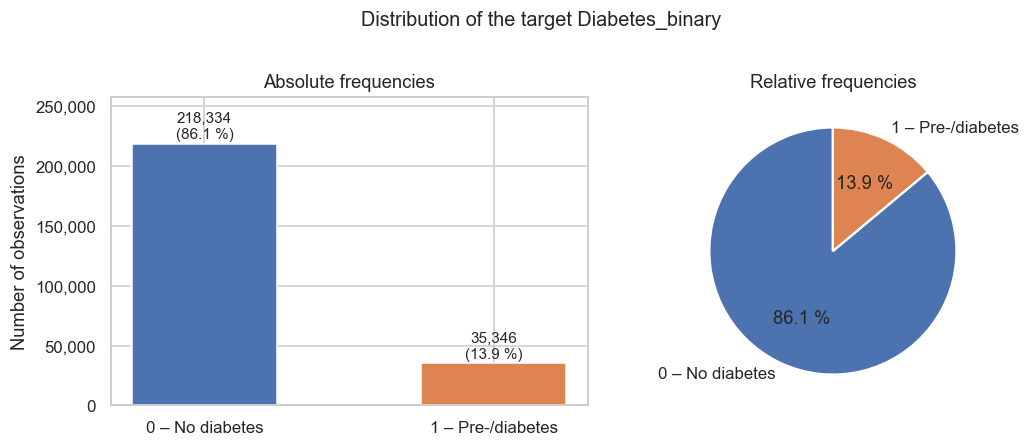

In [5]:
# Class balance of the target: print counts + shares, then a bar + pie figure.
counts = df["Diabetes_binary"].value_counts().sort_index()
labels = ["0 – No diabetes", "1 – Pre-/diabetes"]

print("=== Class distribution ===")
for n, lbl in zip(counts, labels):
    print(f"  {lbl:<20}  {n:>7,}  ({n/counts.sum()*100:.1f} %)")
print(f"\n  Total: {counts.sum():,}")

# --- Plot: absolute (left) and relative (right) frequencies ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: absolute counts as bars, annotated with count + share
axes[0].bar(labels, counts.values, color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.5)
for i, (n, pct) in enumerate(zip(counts.values, counts.values / counts.sum() * 100)):
    axes[0].text(i, n + 1500, f"{n:,}\n({pct:.1f} %)", ha="center", va="bottom", fontsize=10)
axes[0].set_title("Absolute frequencies", fontsize=12)
axes[0].set_ylabel("Number of observations")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].set_ylim(0, counts[0] * 1.18)

# Right: same split as a pie (share of each class)
axes[1].pie(
    counts.values,
    labels=labels,
    autopct="%1.1f %%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Relative frequencies", fontsize=12)

plt.suptitle("Distribution of the target Diabetes_binary", fontsize=13, y=1.01)
plt.tight_layout()

# Save before show() so the canvas isn't already cleared
fig.savefig(OUTPUT_DIR / "04_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The target `Diabetes_binary` is clearly imbalanced. Of 253,680 observations, 218,334 people belong to class 0 (no diabetes), i.e. 86.1 % of the dataset. Class 1 (prediabetes/diabetes) comprises 35,346 people, only 13.9 % of observations.

This is a pronounced class imbalance — which is why accuracy is not a suitable primary metric here (the full metric strategy, with PR-AUC as the primary metric, was derived in NB01 §5).

The class distribution also confirms that the project should be treated as an imbalanced binary-classification problem.

## 5. Duplicate and Label-Consistency Analysis

BRFSS is a cross-sectional telephone survey — each person should be recorded exactly once. Still, identical rows can arise from two sources: genuine repeat participation (rare) or duplicate entry during database cleaning. Beyond that, we ask whether there are feature vectors that appear with conflicting labels: the same feature combination but a different diabetes status. That would be a direct empirical measure of irreducible label noise — noise no model can remove, because it is encoded in the data itself.

We therefore distinguish:
- **Exact duplicates** — identical row across *all* 22 columns including the target
- **Feature duplicates with label conflict** — same 21-dimensional feature vector but different `Diabetes_binary`

In [6]:
feature_cols = [c for c in df.columns if c != "Diabetes_binary"]

# --- Exact duplicates (identical across all 22 columns, features + target) ---
exact_dups     = df.duplicated(keep=False)          # keep=False: flag every row in a duplicate group
n_exact_rows   = exact_dups.sum()
n_exact_groups = df[exact_dups].groupby(df.columns.tolist()).ngroups

print("=== Exact duplicates (all 22 columns) ===")
print(f"  Affected rows : {n_exact_rows:>7,}  ({n_exact_rows/len(df)*100:.2f} %)")
print(f"  Unique groups : {n_exact_groups:>7,}")

# --- Feature duplicates with label conflict ---
# Group by the 21 features; per vector: how many distinct labels (nunique),
# how many rows (count), and its diabetes rate (mean). nunique > 1 = conflict.
label_per_vector = (
    df.groupby(feature_cols)["Diabetes_binary"]
    .agg(["nunique", "count", "mean"])
    .reset_index()
)
conflict_groups   = label_per_vector[label_per_vector["nunique"] > 1]
n_conflict_rows   = conflict_groups["count"].sum()
n_conflict_groups = len(conflict_groups)

print("\n=== Feature duplicates with label conflict ===")
print(f"  Affected rows  : {n_conflict_rows:>7,}  ({n_conflict_rows/len(df)*100:.2f} %)")
print(f"  Unique vectors : {n_conflict_groups:>7,}")

# Irreducible noise: within each conflicting vector, the smaller label share min(p, 1-p)
# is the fraction no model could classify correctly. Weight by group size, sum, normalise.
noise_per_group        = conflict_groups["mean"].apply(lambda p: min(p, 1 - p))
irreducible_noise_rows = (noise_per_group * conflict_groups["count"]).sum()
noise_rate             = irreducible_noise_rows / len(df)

print("\n=== Empirical irreducible noise ===")
print(f"  Estimated affected rows: {irreducible_noise_rows:>8,.0f}  ({noise_rate*100:.2f} %)")

=== Exact duplicates (all 22 columns) ===
  Affected rows :  35,575  (14.02 %)
  Unique groups :  11,369

=== Feature duplicates with label conflict ===
  Affected rows  :   5,218  (2.06 %)
  Unique vectors :   1,566

=== Empirical irreducible noise ===
  Estimated affected rows:    1,640  (0.65 %)


### Interpretation

**Exact duplicates** occur when rows match across all 22 columns (features *and* target). In a coarsely coded telephone survey like BRFSS they are largely unavoidable — many respondents share the same combination of values — and are mostly coincidental profile collisions rather than data errors, so we do **not** delete them. Their main modelling implication is not data quality but **leakage**: identical (feature + label) rows could otherwise fall on both sides of the train/test split and hand the model memorised "free" hits. This is handled in NB03 by a **group-aware split** that keeps all rows sharing a feature vector entirely on one side (see §10).

The **conflict share** (~0.65 % of rows) comes from feature vectors that appear with *both* labels — the same 21-feature profile recorded once as diabetic and once as not. For such rows the best any model can do is predict the majority label, so a fraction must be misclassified no matter how good the model is. Summed, this is an **empirical lower bound on the irreducible error**: even a perfect classifier on this feature set errs on at least ~0.65 % of rows.

Two honesty caveats: (1) it is only a *lower* bound — feature vectors seen just once cannot reveal a conflict in a finite sample, so the true irreducible error is higher; (2) it is far smaller than the broad label noise from **undiagnosed negatives** (NB01 §4), which does not require exact collisions. So ~0.65 % is the floor we can observe directly, not the full noise level.

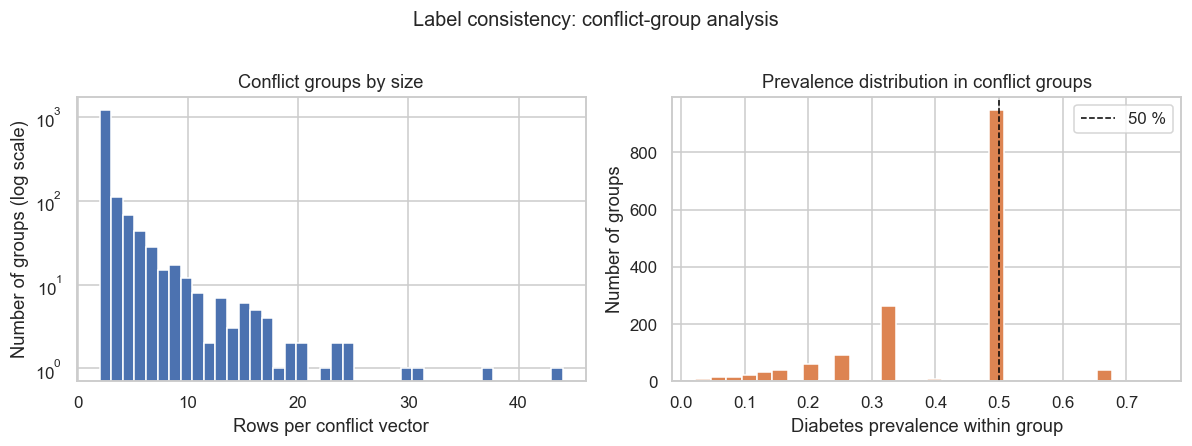

In [7]:
# Visualise the conflict groups: how big they are, and how the label splits within them.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: how many rows share each conflicting vector (log y - most groups are tiny)
axes[0].hist(conflict_groups["count"], bins=40, color="#4C72B0", edgecolor="white", log=True)
axes[0].set_xlabel("Rows per conflict vector")
axes[0].set_ylabel("Number of groups (log scale)")
axes[0].set_title("Conflict groups by size")

# Right: diabetes rate within each conflict group (0.5 = a clean 0/1 split)
axes[1].hist(conflict_groups["mean"], bins=30, color="#DD8452", edgecolor="white")
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1, label="50 %")
axes[1].set_xlabel("Diabetes prevalence within group")
axes[1].set_ylabel("Number of groups")
axes[1].set_title("Prevalence distribution in conflict groups")
axes[1].legend()

plt.suptitle("Label consistency: conflict-group analysis", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "05_conflict_groups.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — label-consistency analysis

The figure reads the conflict groups from two angles.

**Group size (left panel).** Almost all conflict groups are small — 2 to 3 rows (note the log y-axis: the size-2 bar holds ~1,000+ groups, everything larger drops off steeply). Large conflicting vectors (20+ rows) occur only once or twice. Conflicts are thus isolated coincidental collisions, not a systematic coding error.

**Label split within groups (right panel).** A dominant spike sits exactly at a within-group prevalence of 0.5 (~900 groups): most conflicts are simple pairs — the same feature vector labelled 0 once and 1 once (the smaller bars at 0.33, 0.25, 0.2 are larger groups). The distribution is **asymmetric**: groups below 0.5 clearly outnumber those above. In other words, when a profile carries mixed labels, it leans toward 0 (no diabetes). This supports the NB01 hypothesis — undiagnosed or unreported diabetics are coded as negative (FN bias), not the reverse.

Together this confirms that the ~0.65 % conflict share (quantified above) is low-volume, mostly paired, and FN-skewed — consistent with label noise rather than data corruption.

## 6. General Feature Distributions

Before analysing features against the target, we look at their marginal distributions. This serves two purposes: striking distributions (e.g. strongly right-skewed count variables, BMI outliers) can hint at recording artefacts; and the base rates of the binary features help judge whether rare categories will pose a later modelling problem.

### 6.1 Binary features

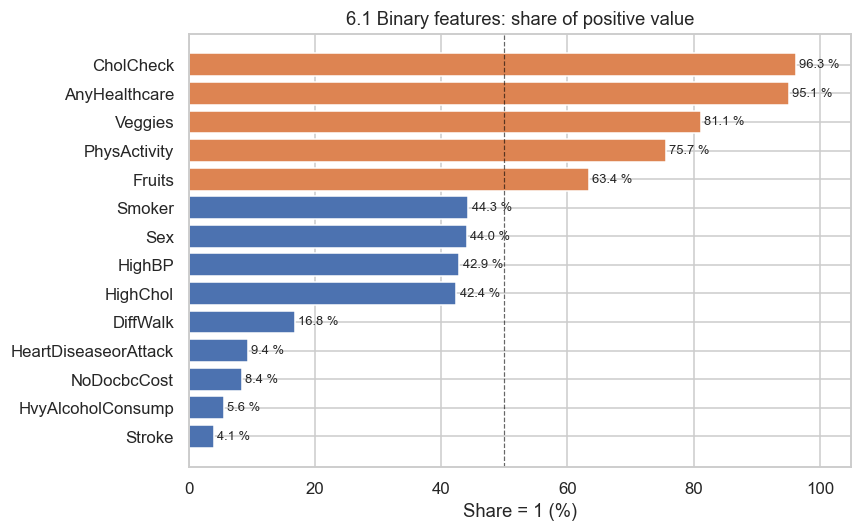

In [8]:
# Define feature groups once - reused in Sections 6, 7, 8, 9
BINARY_COLS  = ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
                "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
                "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex"]
ORDINAL_COLS = ["GenHlth", "Age", "Education", "Income"]
COUNT_COLS   = ["MentHlth", "PhysHlth"]
NUMERIC_COLS = ["BMI"]

# Share of positive value (= 1) per binary feature, sorted ascending
prev_bin = df[BINARY_COLS].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
# colour: blue if the feature is mostly 0 (<50 %), orange if mostly 1 (>=50 %)
colors = ["#4C72B0" if v < 0.5 else "#DD8452" for v in prev_bin.values]
bars = ax.barh(prev_bin.index, prev_bin.values * 100, color=colors, edgecolor="white")
ax.axvline(50, color="black", linestyle="--", linewidth=0.8, alpha=0.6)   # 50/50 reference
for bar, val in zip(bars, prev_bin.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val*100:.1f} %", va="center", fontsize=8.5)
ax.set_xlabel("Share = 1 (%)")
ax.set_xlim(0, 105)
ax.set_title("6.1 Binary features: share of positive value", fontsize=12)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "06_binary_feature_prevalence.png", dpi=150, bbox_inches="tight")
plt.show()

The plot shows the share of positive values (= 1) for all 14 binary features, sorted by frequency.

**Strikingly low variance:** `CholCheck` (96.3 %) and `AnyHealthcare` (95.1 %) are nearly constant. Low variance often goes with weak predictive power, but not necessarily — a rare category can still carry signal if it concentrates in one class (same caveat as the rare events below). This section only records the distribution; predictive value is assessed progressively — bivariately in §7, and decided only later via model-based importance and ablation (Phase 4).

**Good variance:** `HighBP` (42.9 %), `HighChol` (42.4 %), `Smoker` (44.3 %) and `Sex` (44.0 %) are close to 50/50.

**Rare events:** `Stroke` (4.1 %), `HvyAlcoholConsump` (5.6 %), `NoDocbcCost` (8.4 %) and `HeartDiseaseorAttack` (9.4 %) are rare.

The univariate distribution alone does not allow a statement about predictive power — a feature can be rare and still strongly predictive if it is markedly over-represented within the positive class. Predictive value is therefore assessed later (bivariately in §7, definitively via model importance and ablation in Phase 4).

### 6.2 Ordinal features

`GenHlth`, `Age`, `Education` and `Income` are ordinally coded; the distances between categories are not substantively equal. The frequency distribution shows whether individual categories are so rare that they could cause modelling problems.

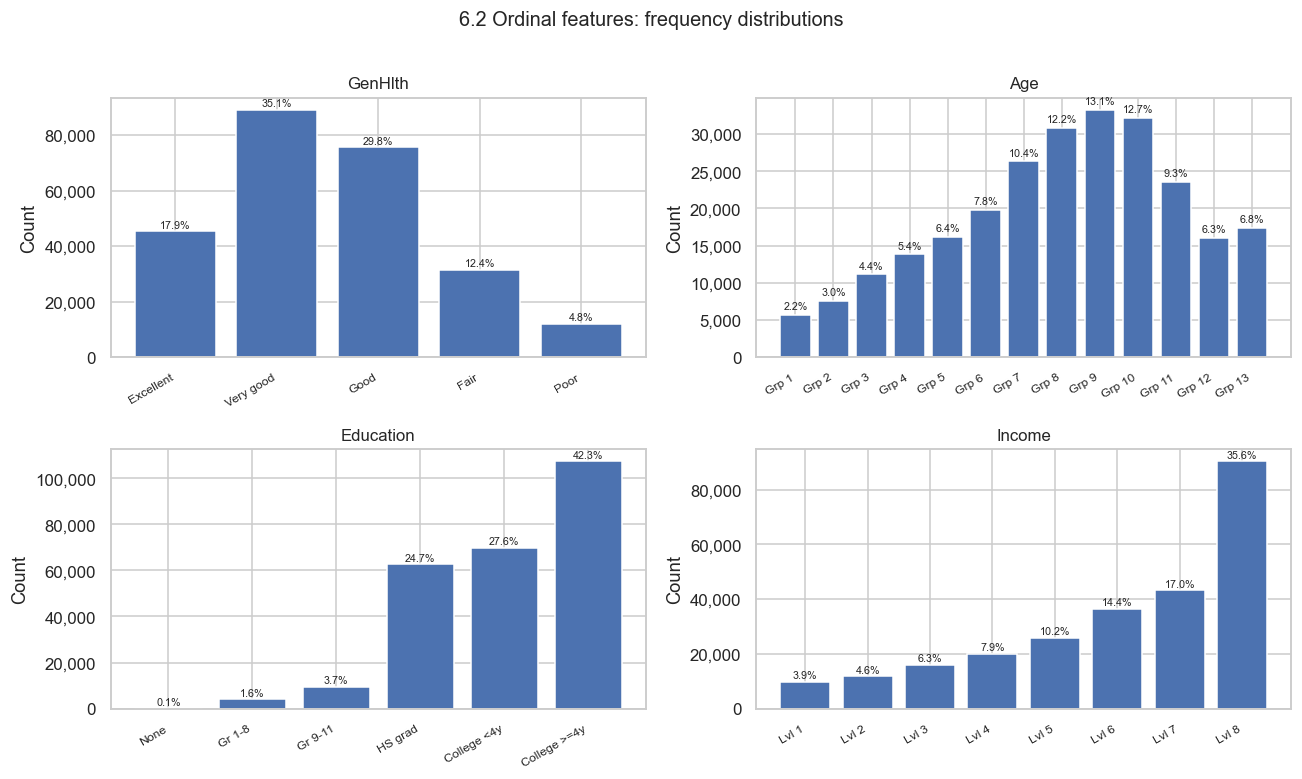

In [9]:
# Human-readable labels for the ordinal categories (code -> meaning)
ordinal_labels = {
    "GenHlth":   {1: "Excellent", 2: "Very good", 3: "Good", 4: "Fair", 5: "Poor"},
    "Age":       {i: f"Grp {i}" for i in range(1, 14)},
    "Education": {1: "None", 2: "Gr 1-8", 3: "Gr 9-11", 4: "HS grad", 5: "College <4y", 6: "College >=4y"},
    "Income":    {i: f"Lvl {i}" for i in range(1, 9)},
}

# One frequency bar chart per ordinal feature, annotated with each category's share (%)
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, col in zip(axes, ORDINAL_COLS):
    counts = df[col].value_counts().sort_index()
    labels = [ordinal_labels[col].get(k, str(k)) for k in counts.index]
    bars = ax.bar(range(len(counts)), counts.values, color="#4C72B0", edgecolor="white")
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar, n in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                f"{n/len(df)*100:.1f}%", ha="center", va="bottom", fontsize=7)

plt.suptitle("6.2 Ordinal features: frequency distributions", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "06_2_ordinal_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

**GenHlth** is well spread across all five levels, with most mass on "Very good" (35.1 %) and "Good" (29.8 %); only 4.8 % report poor health. The distribution is slightly left-skewed and has ample variance across categories.

**Age** is roughly bell-shaped, peaking in the middle bands (Grp 9-10, ~60-69 years); the youngest bands (Grp 1-3) are under-represented.

**Education** is strongly right-skewed: 42.3 % hold a college degree (>= 4 years), while the lowest levels together make up under 6 % — mass piles up at the top (ceiling effect) and the low categories are sparse.

**Income** shows the same pattern: the open-ended top level 8 (>= $75k) dominates at 35.6 %, with the distribution rising monotonically toward it.

**Consequence:** Education and Income show a ceiling effect (mass at the top) with sparsely populated low categories. Whether this limits predictive value is examined bivariately in §7 and settled via model importance / ablation in Phase 4.

### 6.3 Count and numeric features

`MentHlth` and `PhysHlth` are count variables (days of poor health in the past 30 days, 0-30); `BMI` is integer-rounded with a wide range. We look at their distributions and, for BMI, at its extreme values.

BMI  - Median: 27  |  P1: 18  |  P99: 50  |  Extreme values (outside P1/P99): 3,499 (1.38 %)
MentHlth - 0-share: 69.3 %  |  30-share: 4.8 %  |  Median: 0
PhysHlth - 0-share: 63.1 %  |  30-share: 7.6 %  |  Median: 0


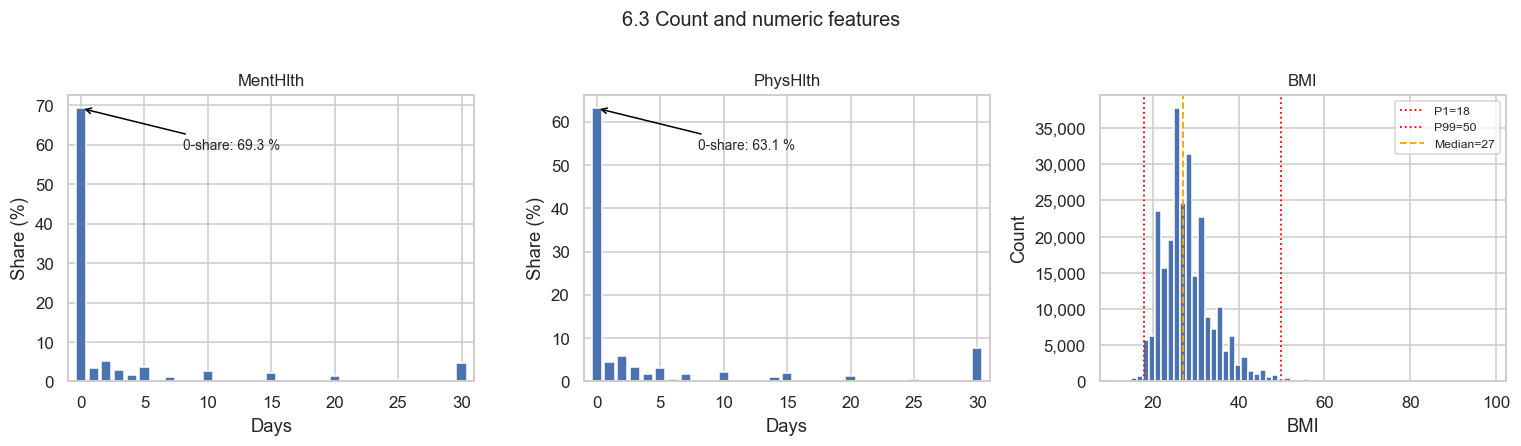

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# MentHlth & PhysHlth: discrete bar chart (0-30), with an arrow marking the 0-day bar
for ax, col in zip(axes[:2], COUNT_COLS):
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values / len(df) * 100, color="#4C72B0", edgecolor="white", width=0.8)
    zero_pct = df[col].eq(0).mean() * 100
    ax.annotate(f"0-share: {zero_pct:.1f} %", xy=(0, counts[0] / len(df) * 100),
                xytext=(8, counts[0] / len(df) * 100 * 0.85),
                arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Days")
    ax.set_ylabel("Share (%)")
    ax.set_xlim(-1, 31)

# BMI: histogram with median + P1/P99 lines marked
ax = axes[2]
ax.hist(df["BMI"], bins=60, color="#4C72B0", edgecolor="white")
for pct, ls in [(1, ":"), (99, ":")]:
    v = np.percentile(df["BMI"], pct)
    ax.axvline(v, color="red", linestyle=ls, linewidth=1.2, label=f"P{pct}={v:.0f}")
ax.axvline(df["BMI"].median(), color="orange", linestyle="--", linewidth=1.2,
           label=f"Median={df['BMI'].median():.0f}")
ax.set_title("BMI", fontsize=11)
ax.set_xlabel("BMI")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=8)

# Summary stats: BMI extremes (outside P1/P99) + zero/30 shares of the count features
bmi_p1, bmi_p99 = np.percentile(df["BMI"], [1, 99])
n_extreme = df["BMI"].gt(bmi_p99).sum() + df["BMI"].lt(bmi_p1).sum()
print(f"BMI  - Median: {df['BMI'].median():.0f}  |  P1: {bmi_p1:.0f}  |  P99: {bmi_p99:.0f}  "
      f"|  Extreme values (outside P1/P99): {n_extreme:,} ({n_extreme/len(df)*100:.2f} %)")
for col in COUNT_COLS:
    print(f"{col} - 0-share: {df[col].eq(0).mean()*100:.1f} %  |  "
          f"30-share: {df[col].eq(30).mean()*100:.1f} %  |  Median: {df[col].median():.0f}")

plt.suptitle("6.3 Count and numeric features", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "06_3_count_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

**MentHlth and PhysHlth** are zero-inflated count variables (days of poor health in the past 30 days). Both are dominated by 0: 69.3 % and 63.1 % of respondents report no bad day at all, so the median is 0 in each case. A second, smaller peak sits at 30 days (4.8 % and 7.6 %) — a survey anchoring effect, where respondents with permanent impairment pick "30" as a proxy for "always". The resulting bimodal shape (mass at 0 and 30, little in between) is a known property of BRFSS health questions, not a measurement error. Tree-based models handle this distribution directly; linear models would need a transformation.

**BMI** is right-skewed with a median of 27 (the WHO normal/overweight boundary). The P1-P99 range is 18 to 50, with only 1.38 % of values outside it (3,499 rows) — almost all on the upper side, so extreme obesity is present in the data while underweight is barely. Values above 60 are physiologically possible but rare. The median of 27 lies in the overweight range, matching the real US population distribution, and is not a data defect.

**Consequence for Phase 3:** neither count feature is treated as a classic outlier — high values can be meaningful, and tree-based models tolerate zero-inflation. Whether to re-encode them (e.g. a hurdle encoding splitting "any bad days" from "how many") is examined in Phase 3 (see §9.1). For BMI, a percentile cap (~P1/P99, i.e. roughly 18/50 on the full data) is considered, with the exact cut-points re-derived on the training split (see §9.2 and NB03) so that no full-data quantity enters the fitted pipeline.

## 7. Feature-Target Relationships

We now link the marginal distributions to the target. The goal is to quantify which features are most strongly associated with `Diabetes_binary` — purely descriptive, no causal claim. This analysis informs the later feature selection and helps interpret the model's results.

*(Reminder, see §1.2: Sections 7-9 break the data down by the target on the full dataset, for exploration only. Nothing computed here enters the model as a fitted parameter — any cut-point is re-derived on the training split in NB03.)*

### 7.1 Diabetes prevalence per binary feature

For each binary feature we compute the diabetes rate separately for the negative (= 0) and positive (= 1) value. The difference (delta) between the two shows how strongly the feature is associated with the target.

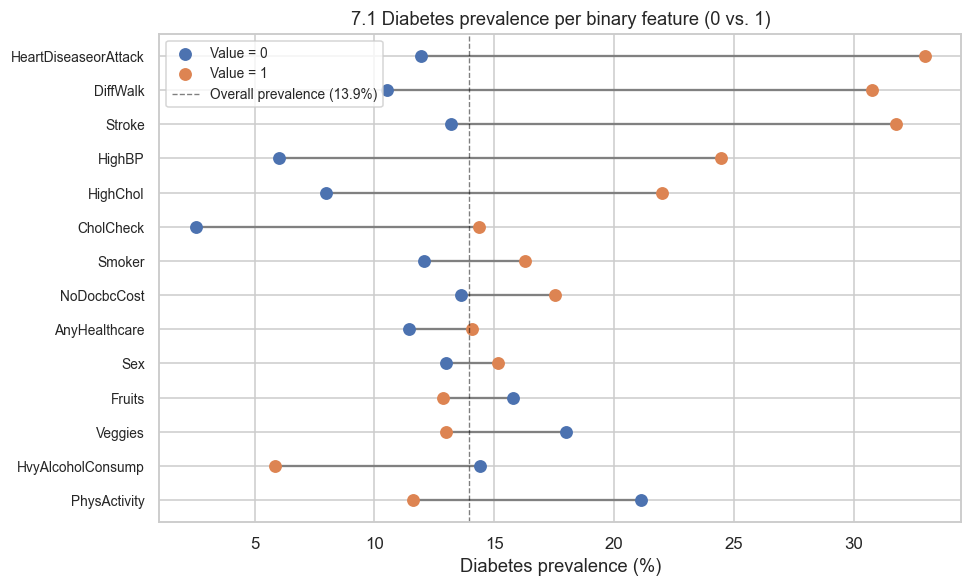


Delta ranking (largest difference first):
             Feature Prev (=0) Prev (=1)  Delta
HeartDiseaseorAttack     12.0%     33.0% +21.0%
            DiffWalk     10.5%     30.7% +20.2%
              Stroke     13.2%     31.8% +18.6%
              HighBP      6.0%     24.4% +18.4%
            HighChol      8.0%     22.0% +14.0%
           CholCheck      2.5%     14.4% +11.8%
              Smoker     12.1%     16.3%  +4.2%
         NoDocbcCost     13.6%     17.5%  +3.9%
       AnyHealthcare     11.5%     14.1%  +2.6%
                 Sex     13.0%     15.2%  +2.2%
              Fruits     15.8%     12.9%  -2.9%
             Veggies     18.0%     13.0%  -5.0%
   HvyAlcoholConsump     14.4%      5.8%  -8.6%
        PhysActivity     21.1%     11.6%  -9.5%


In [11]:
# Diabetes rate within each binary feature, split by its value (0 vs 1).
# Delta = prevalence(=1) - prevalence(=0): how strongly the feature separates the target.
rows = []
for col in BINARY_COLS:
    p0 = df.loc[df[col] == 0, "Diabetes_binary"].mean()
    p1 = df.loc[df[col] == 1, "Diabetes_binary"].mean()
    rows.append({"Feature": col, "Prev (=0)": p0, "Prev (=1)": p1, "Delta": p1 - p0})

assoc_df = pd.DataFrame(rows).sort_values("Delta")

# Dumbbell plot: one line per feature linking its prevalence at value 0 (blue) and value 1 (orange)
fig, ax = plt.subplots(figsize=(9, 5.5))
y = range(len(assoc_df))

ax.hlines(y, assoc_df["Prev (=0)"] * 100, assoc_df["Prev (=1)"] * 100,
          color="gray", linewidth=1.5, zorder=1)
ax.scatter(assoc_df["Prev (=0)"] * 100, y, color="#4C72B0", s=55, zorder=2, label="Value = 0")
ax.scatter(assoc_df["Prev (=1)"] * 100, y, color="#DD8452", s=55, zorder=2, label="Value = 1")
ax.axvline(df["Diabetes_binary"].mean() * 100, color="black", linestyle="--",
           linewidth=0.9, alpha=0.5, label=f"Overall prevalence ({df['Diabetes_binary'].mean()*100:.1f}%)")

ax.set_yticks(list(y))
ax.set_yticklabels(assoc_df["Feature"], fontsize=9)
ax.set_xlabel("Diabetes prevalence (%)")
ax.set_title("7.1 Diabetes prevalence per binary feature (0 vs. 1)", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "07_1_binary_prevalence.png", dpi=150, bbox_inches="tight")
plt.show()

# Ranking table, largest separation first
print("\nDelta ranking (largest difference first):")
print(assoc_df.sort_values("Delta", ascending=False)
      .assign(**{"Prev (=0)": lambda d: d["Prev (=0)"].map("{:.1%}".format),
                 "Prev (=1)": lambda d: d["Prev (=1)"].map("{:.1%}".format),
                 "Delta":     lambda d: d["Delta"].map("{:+.1%}".format)})
      .to_string(index=False))

The plot shows diabetes prevalence split by feature value (0 vs. 1), sorted by the absolute prevalence difference delta.

**Largest positive associations (delta > 10 %):** HeartDiseaseorAttack (+21 %), DiffWalk (+20.2 %), Stroke (+18.6 %) and HighBP (+18.4 %) show the largest gaps. This is substantively plausible — these variables form a classic comorbidity cluster: cardiovascular disease, high blood pressure and limited mobility are known accompanying and downstream conditions of type-2 diabetes. **Stroke and HeartDiseaseorAttack should be read as comorbidity markers — not as early risk factors.** They indicate that a high disease burden already exists, shifting the model's interpretation from early detection toward risk assessment of existing high-risk profiles. HighChol (+14 %) extends the same cardiometabolic cluster.

**CholCheck — a large gap for a different reason.** CholCheck (+11.8 %) also shows a large gap, but it is *not* a comorbidity: those without a cholesterol check (= 0) show only 2.5 % diabetes prevalence — the lowest value of any feature. This is not a protective effect but a diagnosis bias: without a doctor's visit, no diabetes diagnosis. CholCheck partly measures use of medical care, not health status.

**Weak associations (|delta| < 5 %):** Smoker, NoDocbcCost, AnyHealthcare, Sex, Fruits and Veggies show only small differences. Their bivariate signal is weak; whether they retain any signal alongside the stronger features is decided by the multivariate models (Phase 4).

**Negative associations:** PhysActivity (-9.5 %) and HvyAlcoholConsump (-8.6 %) go together with lower diabetes prevalence. PhysActivity is expected. HvyAlcoholConsump is counter-intuitive — a possible explanation is survivorship or healthy-user bias: diabetics reduce alcohol after diagnosis, or heavy drinkers are younger on average. This is not to be read causally.

**Caveat:** all deltas are bivariate, unadjusted associations — they do not separate a feature's own contribution from shared drivers (age, income, GenHlth). The multivariate models use all features jointly, so a feature's apparent signal may shrink in the presence of correlated ones; note this is predictive conditioning, not causal confounding-adjustment.

### 7.2 Group comparison for ordinal and numeric features

For the ordinal features we look at diabetes prevalence per category as a line — a monotone increase (or decrease) would indicate an ordered relationship that tree-based models can capture without encoding. For `BMI`, `MentHlth` and `PhysHlth` we compare the class distributions via KDE plots.

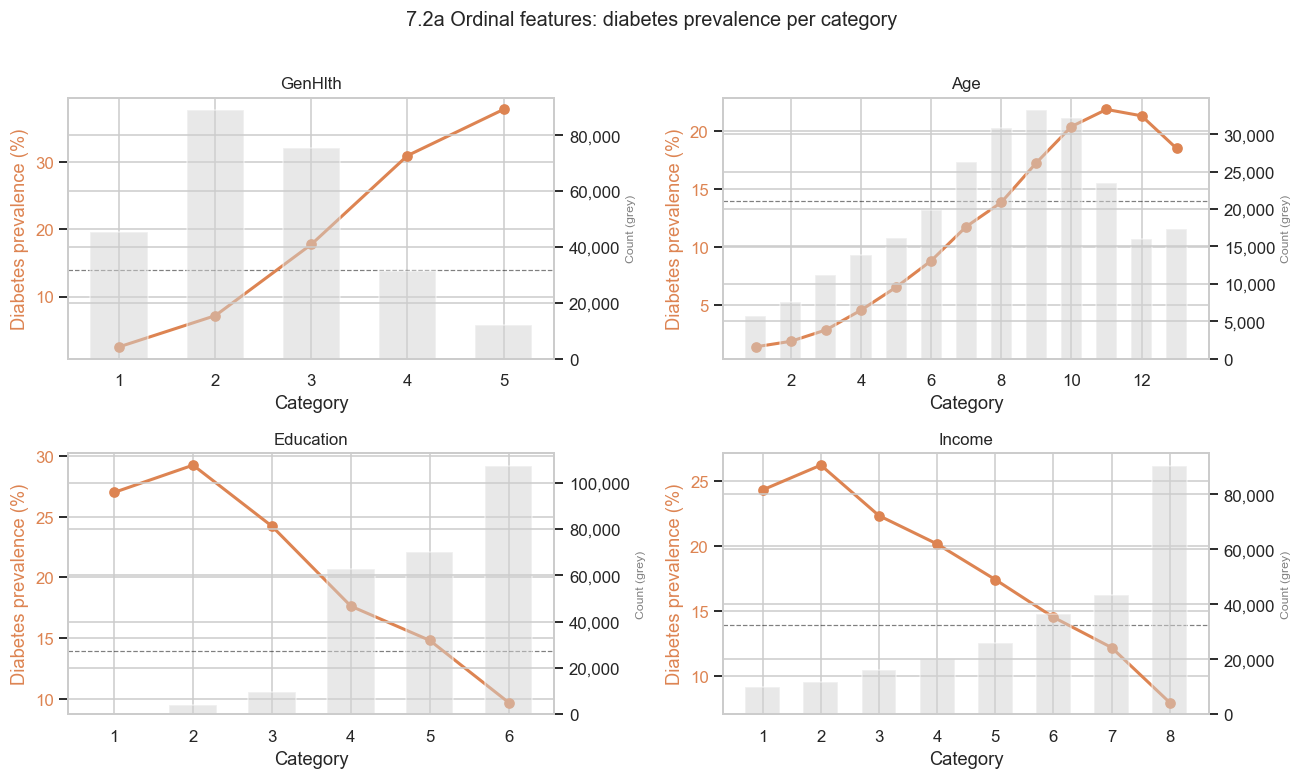

In [12]:
# --- Ordinal features: diabetes prevalence per category (line) + category counts (grey bars) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, col in zip(axes, ORDINAL_COLS):
    prev = df.groupby(col)["Diabetes_binary"].mean() * 100   # prevalence per category
    n_per_cat = df[col].value_counts().sort_index()          # how many rows per category

    # grey background bars (counts) on a secondary axis - shows where the data mass sits
    ax2 = ax.twinx()
    ax2.bar(prev.index, n_per_cat.reindex(prev.index), color="lightgray", alpha=0.5, width=0.6, zorder=0)
    ax2.set_ylabel("Count (grey)", fontsize=8, color="gray")
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    # prevalence line (orange) + overall-prevalence reference
    ax.plot(prev.index, prev.values, marker="o", color="#DD8452", linewidth=2, zorder=3)
    ax.axhline(df["Diabetes_binary"].mean() * 100, color="black", linestyle="--",
               linewidth=0.8, alpha=0.5)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Category")
    ax.set_ylabel("Diabetes prevalence (%)", color="#DD8452")
    ax.tick_params(axis="y", labelcolor="#DD8452")

plt.suptitle("7.2a Ordinal features: diabetes prevalence per category", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "07_2a_ordinal_prevalence.png", dpi=150, bbox_inches="tight")
plt.show()

All four ordinal features show largely ordered relationships between category and diabetes prevalence — with individual exceptions that are substantively explainable.

**GenHlth** shows the strongest and smoothest increase of all features: from ~4 % prevalence at "Excellent" (cat. 1) to ~37 % at "Poor" (cat. 5). The curve crosses the overall prevalence (13.9 %) already at cat. 3 ("Good"). GenHlth is thus bivariately the strongest single predictor in the dataset.

**Age** rises from ~2 % (youngest band) to ~21 % (Grp 11-12), then dips slightly in Grp 13 (oldest band). This decline is plausibly a survivorship effect: the oldest cohort contains disproportionately healthy survivors; the severely ill are less reachable in telephone surveys.

**Education** shows an inverse relationship: low education (cat. 1-2) ~27-29 %, highest education (cat. 6) ~10 %. Cat. 2 lies slightly above cat. 1, which should not be over-interpreted given the very small sample in cat. 1 (only 0.1 % of the data).

**Income** falls almost uniformly from ~24-26 % at the lowest income to ~9 % at the highest — the clearest inverse relationship among the four features.

**Joint conclusion:** the ordered relationships support the ordinal coding, which suits the tree-based models directly; for the linear baseline the minor non-monotonicities (Age, Education) are a mild approximation. One-hot encoding would discard the substantive order and is not used. The encoding decision is fixed in Phase 3.

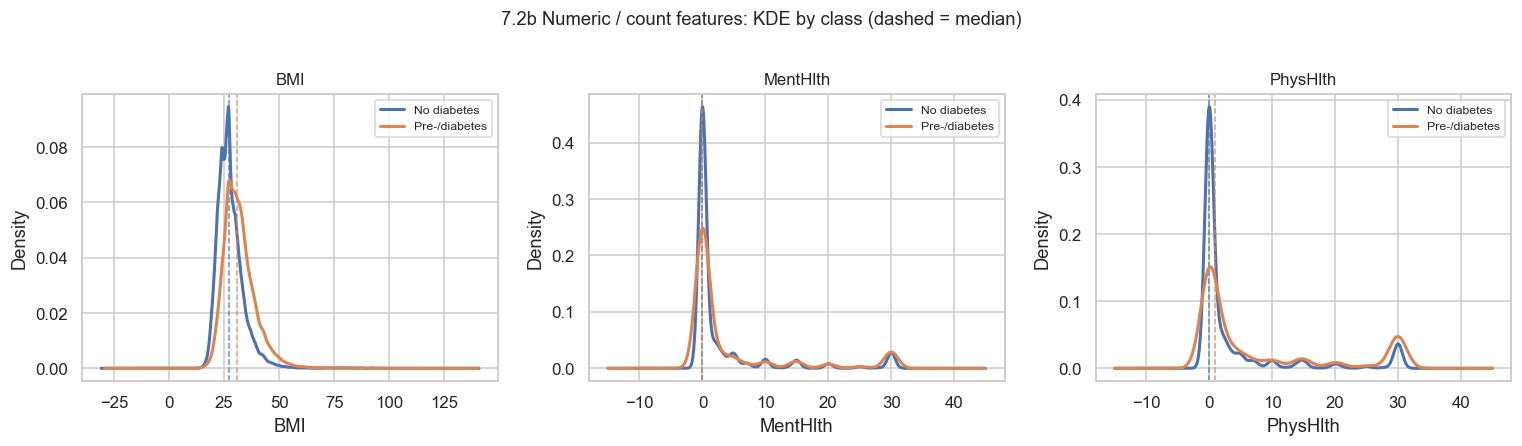

Median comparison (Diabetes=0 vs. Diabetes=1):
  BMI           no diabetes: 27.0   diabetes: 31.0   delta=+4.0
  MentHlth      no diabetes: 0.0   diabetes: 0.0   delta=+0.0
  PhysHlth      no diabetes: 0.0   diabetes: 1.0   delta=+1.0


In [13]:
# --- Numeric / count features: class-split distribution via KDE (dashed line = median) ---
palette    = {0: "#4C72B0", 1: "#DD8452"}
labels_map = {0: "No diabetes", 1: "Pre-/diabetes"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, NUMERIC_COLS + COUNT_COLS):
    # one KDE curve per class, plus a dashed median line in the matching colour
    for cls in [0, 1]:
        subset = df.loc[df["Diabetes_binary"] == cls, col]
        subset.plot.kde(ax=ax, color=palette[cls], linewidth=2, label=labels_map[cls])
        ax.axvline(subset.median(), color=palette[cls], linestyle="--", linewidth=1, alpha=0.8)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    # Note: KDE suits BMI (continuous); for the zero-inflated counts it over-smooths the spike at 0 -
    # the median comparison below is the robust class signal for those.

plt.suptitle("7.2b Numeric / count features: KDE by class (dashed = median)", fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "07_2b_numeric_kde.png", dpi=150, bbox_inches="tight")
plt.show()

# Robust class comparison: median per class and their difference
print("Median comparison (Diabetes=0 vs. Diabetes=1):")
for col in NUMERIC_COLS + COUNT_COLS:
    m0 = df.loc[df["Diabetes_binary"] == 0, col].median()
    m1 = df.loc[df["Diabetes_binary"] == 1, col].median()
    print(f"  {col:<12}  no diabetes: {m0:.1f}   diabetes: {m1:.1f}   delta={m1-m0:+.1f}")

*KDE note: the smooth curves suit BMI (continuous); for the zero-inflated counts (MentHlth, PhysHlth) the KDE over-smooths the spike at 0 and can bleed into negative days, so for those the median comparison and the discrete view in §6.3 are the reliable signal.*

**BMI** shows the clearest class difference of the three. The diabetes group (orange) is shifted right of the non-diabetes group (blue) — median 31 vs. 27 (delta = +4) — and its curve is flatter and wider, i.e. more spread at higher BMI. This is a clear bivariate association, consistent with the known obesity / type-2-diabetes link.

**MentHlth** shows essentially no class difference — both medians are 0 (delta = 0) and the curves nearly coincide. Its bivariate signal is negligible.

**PhysHlth** sits in between: median 0 (no diabetes) vs. 1 (diabetes), delta = +1 — a small but consistent shift (the diabetes group has somewhat less mass at 0 and a bit more toward 30 days). A weak bivariate association.

The "rounding bias" — answers clustering at multiples of 5 and 10 — is a known BRFSS artefact, visible in the discrete bar charts of §6.3 rather than in these smoothed curves.

## 8. Multivariate Analysis: Spearman Rank Correlation

For a full correlation analysis of a mixed dataset (binary, ordinal, count, numeric), Spearman's rho is more suitable than Pearson's r: it assumes no normality, is robust to outliers, and captures monotone — not necessarily linear — relationships. Since all features are stored as integer codes, `scipy.stats.spearmanr` can be applied directly to the whole DataFrame.

We consider three perspectives:

1. **Heatmap of all features + target** — overview of the full correlation structure
2. **Top-10 feature <-> target** — strongest associations by |rho|
3. **Top-15 inter-feature pairs (without target)** — strongest redundancies / collinearities

### 8.1 Full correlation matrix (heatmap)

The bivariate analysis in Section 7 examined features one at a time against the target. Here we look at all 22 columns simultaneously: which features correlate not only with the target but also with each other? Only the full picture reveals clusters of redundant variables and potential multicollinearity — both relevant for feature selection and regularisation in Phases 3 and 4.

**Why Spearman and not Pearson?**

Pearson measures linear relationships and assumes interval scaling — equal distances between all values. That does not hold here for most features:

| Group | Features | Problem with Pearson |
|---|---|---|
| Binary (14x) | HighBP, HighChol, ... | Only two values, no distances |
| Ordinal (4x) | GenHlth, Age, Education, Income | Ordered, but distances not equal |
| Count (2x) | MentHlth, PhysHlth | Zero-inflated, strongly right-skewed |
| Numeric (1x) | BMI | Right-skewed, extreme values |

Spearman instead works with **ranks**: each value is replaced by its rank in the sorted list before correlating. This makes Spearman:

- **Scale-agnostic** — only the order matters, not the absolute distances
- **Robust to outliers** — an extreme BMI simply becomes the highest rank
- **Sensitive to monotone relationships** — including non-linear ones, as long as they are consistently increasing or decreasing

For the binary features the rank transform makes little difference (two values = two ranks, so Spearman ≈ Pearson there); the advantage applies mainly to the ordinal, count and skewed-numeric features. Using Spearman uniformly keeps a single comparable measure across the whole mixed frame.

*Note: the colour scale is capped at ±0.5 (no pair exceeds it), so colours are saturated already at moderate ρ — read the annotated values, not colour intensity alone.*

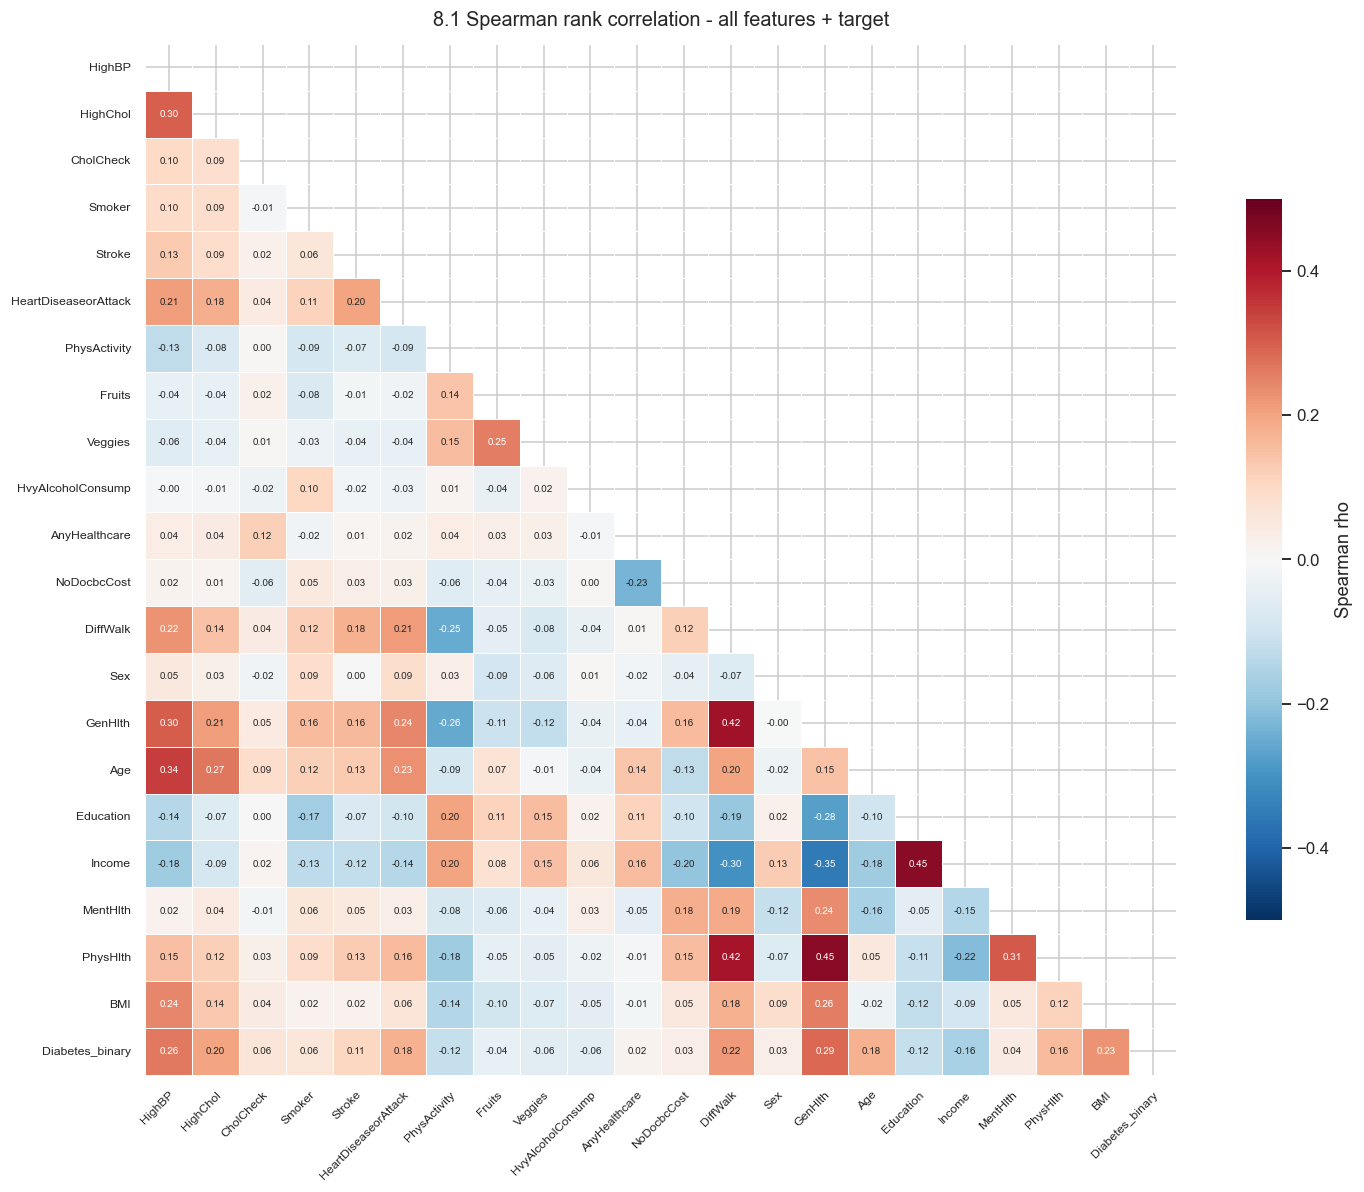

In [14]:
# Spearman correlation matrix over all 22 columns (21 features + target).
# spearmanr returns an (n,n) array; we convert it to a DataFrame.
col_order = BINARY_COLS + ORDINAL_COLS + COUNT_COLS + NUMERIC_COLS + ["Diabetes_binary"]
df_ordered = df[col_order]

corr_matrix, _ = stats.spearmanr(df_ordered)
corr_df = pd.DataFrame(corr_matrix, index=col_order, columns=col_order)

mask = np.triu(np.ones_like(corr_df, dtype=bool))   # show only the lower triangle (hide mirror + diagonal)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_df,
    mask=mask,
    cmap="RdBu_r",
    vmin=-0.5, vmax=0.5,   # capped at +/-0.5: no pair exceeds it; uses the full colour range (colours look strong at moderate rho - read the numbers)
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6.5},
    linewidths=0.4,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.7, "label": "Spearman rho"},
    ax=ax,
)
ax.set_title("8.1 Spearman rank correlation - all features + target", fontsize=13, pad=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=8)
ax.tick_params(axis="y", labelsize=8, rotation=0)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "08_1_spearman_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

**1. No severe multicollinearity.** No feature pair exceeds |rho| = 0.5. The strongest inter-feature correlations are Income x Education (rho = 0.45) and PhysHlth x GenHlth (rho = 0.45), followed by GenHlth x DiffWalk (rho = 0.42) and PhysHlth x DiffWalk (rho = 0.42). For tree-based models this is irrelevant; for the logistic-regression baseline a VIF check in Phase 3 is recommended, since several moderate correlations can cumulatively lead to unstable coefficients.

**2. Three structural clusters.**

*Cardiovascular cluster:* HighBP x HighChol (rho = 0.30), HighBP x HeartDiseaseorAttack (rho = 0.21), Stroke x HeartDiseaseorAttack (rho = 0.20), Age x HighBP (rho = 0.34), Age x HighChol (rho = 0.27). These variables measure related cardiometabolic states and all correlate positively with the target (rho = 0.18-0.26). Consistent with the definition of metabolic syndrome (Alberti et al., 2009) and motivates a composite feature in Phase 3.

*Physical-health cluster:* GenHlth x PhysHlth (rho = 0.45), GenHlth x DiffWalk (rho = 0.42), PhysHlth x DiffWalk (rho = 0.42), PhysHlth x MentHlth (rho = 0.31). These features measure physical and subjective impairment from different perspectives (subjective health, bad days, walking difficulty) and are the strongest single bivariate associations with the target (rho = 0.22-0.29).

*Socioeconomic cluster:* Income x Education (rho = 0.45), Income x GenHlth (rho = -0.35), Income x NoDocbcCost (rho = -0.30), Income x DiffWalk (rho = -0.30). Higher income and more education go together with better health and lower diabetes prevalence (rho = -0.12 to -0.16). Consistent with the epidemiological literature on social determinants of diabetes (Agardh et al., 2011).

**3. Weak overall signal vs. the target.** AnyHealthcare correlates negligibly with the target (rho = 0.02; its only notable link is rho = 0.23 with NoDocbcCost) — genuinely weak and a plausible drop candidate. CholCheck is a subtler case: its global correlation is also weak (rho ≈ 0.06), but only because it is near-constant (96 % = 1). Its rare "0" category is in fact highly distinctive (2.5 % prevalence — the diagnosis-proxy signal from §7.1), so the weak rho reflects low volume, not absence of signal. Whether either feature stays is decided by model importance / ablation (Phase 4), not here.

**4. Counter-intuitive finding (MentHlth).** MentHlth correlates barely with the target (rho = 0.04), although the bivariate analysis in §7 showed a visible — if weak — prevalence difference. Spearman captures monotone relationships; with a zero-inflated distribution (69 % zeros) the information is spread unevenly across the ranks, which dampens the global coefficient. Phase 3 will therefore *test* a hurdle encoding for MentHlth (indicator "any bad days" + value) to check whether a separated effect emerges; whether it is kept is decided by ablation in Phase 4. (PhysHlth is not counter-intuitive — its correlation with the target is genuinely moderate, see the physical-health cluster above; its own hurdle motivation comes from the class-relative outlier structure in §9.1.)

HvyAlcoholConsump correlates weakly negatively with the target (rho = -0.06). As discussed in §7, this is not a protective effect but selection bias — people with serious chronic illness consume less alcohol. Not interpreted causally.

**Consequences for Phase 3:**
- Cardiovascular composite from HighBP, HighChol, HeartDiseaseorAttack, Stroke
- Physical-health composite from GenHlth, PhysHlth, DiffWalk
- Consider a socioeconomic composite from Income + Education
- VIF check before logistic regression
- MentHlth as hurdle encoding: `MentHlth_any` (0/1) + `MentHlth_days` (value if > 0)
- CholCheck and AnyHealthcare flagged for review, decided after the feature-importance comparison in Phase 4

### 8.2 Top-10 features by correlation with the target

The heatmap in 8.1 shows all pairwise relationships simultaneously — to identify the features most strongly associated with the target, a focused view is more useful. We extract the ten features with the highest absolute Spearman correlation to the target and visualise them with sign.

This list later serves as a benchmark for model-based feature importance (gain, permutation importance, SHAP): if the data-based top associations match the features the model actually relies on, that is a validity signal. Larger deviations would need explanation — e.g. non-linear interactions that Spearman does not capture.

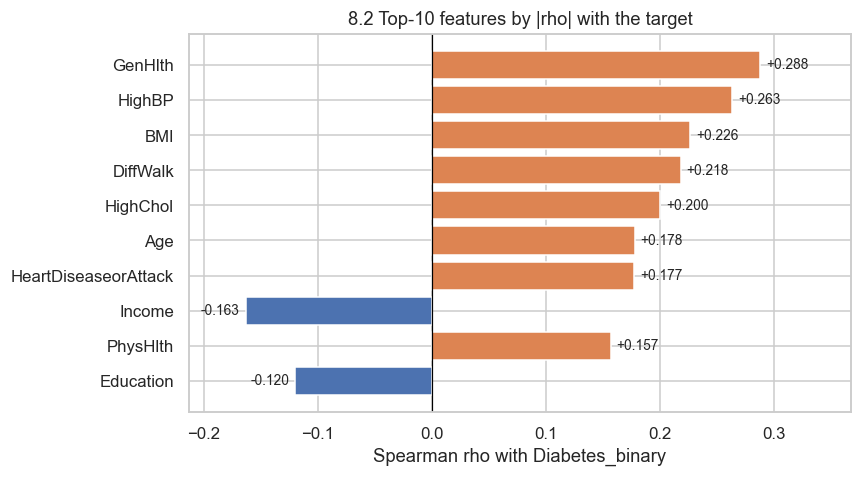

Top-10 feature <-> target (Spearman rho):
                           rho     |rho|
GenHlth               0.287697  0.287697
HighBP                0.263129  0.263129
BMI                   0.226314  0.226314
DiffWalk              0.218344  0.218344
HighChol              0.200276  0.200276
Age                   0.177684  0.177684
HeartDiseaseorAttack  0.177282  0.177282
Income               -0.163305  0.163305
PhysHlth              0.156752  0.156752
Education            -0.120038  0.120038


In [15]:
# --- 8.2 Top-10 features by |rho| with the target ---
target_corr = (
    corr_df["Diabetes_binary"]
    .drop("Diabetes_binary")
    .rename("rho")
    .to_frame()
    .assign(abs_rho=lambda d: d["rho"].abs())
    .sort_values("abs_rho", ascending=False)
)

top10 = target_corr.head(10)

# Horizontal bars coloured by sign (orange = positive, blue = negative), annotated with rho
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#DD8452" if r > 0 else "#4C72B0" for r in top10["rho"]]
bars = ax.barh(top10.index[::-1], top10["rho"][::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, top10["rho"][::-1]):
    xpos = val + (0.005 if val >= 0 else -0.005)
    ha = "left" if val >= 0 else "right"
    ax.text(xpos, bar.get_y() + bar.get_height() / 2, f"{val:+.3f}", va="center", ha=ha, fontsize=9)
ax.set_xlabel("Spearman rho with Diabetes_binary")
ax.set_title("8.2 Top-10 features by |rho| with the target", fontsize=12)
ax.set_xlim(min(top10["rho"].min() - 0.05, -0.05), max(top10["rho"].max() + 0.08, 0.05))
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "08_2_top10_target.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top-10 feature <-> target (Spearman rho):")
print(top10.rename(columns={"abs_rho": "|rho|"}).to_string())

**Interpretation:**

**Strength of the relationships.** All ten top correlations lie in the range |rho| = 0.12-0.29 — weak to moderate. No single feature dominates; diabetes status is explained by the **interplay of several variables**. This is consistent with a multifactorial disease process and argues for non-linear models that capture feature interactions (gradient boosting, random forests) over purely additive approaches.

**Substantive hierarchy.** The five most strongly correlated features form a clearly interpretable core:

1. **GenHlth** (rho = +0.288) — subjectively poor health, the strongest single correlate
2. **HighBP** (rho = +0.263) — high blood pressure, classic cardiometabolic marker
3. **BMI** (rho = +0.226) — overweight / obesity, established main risk factor
4. **DiffWalk** (rho = +0.218) — mobility limitation, downstream symptom or comorbidity
5. **HighChol** (rho = +0.200) — cholesterol problems, part of the metabolic cluster

This ordering is broadly consistent with §7 — the same general-health and cardiometabolic features dominate — but not identical to the binary delta ranking in §7.1: delta and rho are different measures, and rho is attenuated for rare binaries (e.g. HeartDiseaseorAttack has the largest binary delta but only moderate rho, since few respondents are positive).

**Inverse associations.** Income (rho = -0.163) and Education (rho = -0.120) appear in the top 10. The sign is not interpreted causally but confirms the socioeconomic gradient from §8.1: higher income and more education go together with lower diabetes prevalence.

**What is missing from the top 10.** Notable is the **absence of behavioural variables** — PhysActivity, Smoker, Fruits, Veggies and HvyAlcoholConsump are all below |rho| = 0.13. Behaviour correlates markedly more weakly with the target than somatic markers and socioeconomic variables. A plausible explanation: self-reported behaviour carries recall and social-desirability bias, while diagnoses (HighBP, HighChol) are clinically anchored. Phase 4 checks whether behavioural features in combination (e.g. a lifestyle composite) still add value.

**Consequences for later modelling:**
- The five top correlates serve as a **reference** against the model-based feature importance in Phase 4.
- Since no feature reaches |rho| > 0.3, a single-feature heuristic is insufficient — multivariate models are required.
- Socioeconomic variables (Income, Education) belong in the final feature set, even if their individual contribution is moderate.

### 8.3 Strongest inter-feature correlations

The heatmap in 8.1 shows all feature relationships as a surface — to identify structural clusters and potential multicollinearity, a sorted top list is clearer. We extract the fifteen pairs with the highest absolute Spearman correlation, **without** the target. This list has two methodological functions:

- **Identify composite candidates:** features that correlate highly with each other and also correlate with the target (per 8.2) are the most plausible building blocks for combined scores in Phase 3.
- **Assess multicollinearity for the LogReg baseline:** at |rho| > 0.7 coefficients would be unstable. With several moderate correlations the effect accumulates; a VIF check is then recommended.

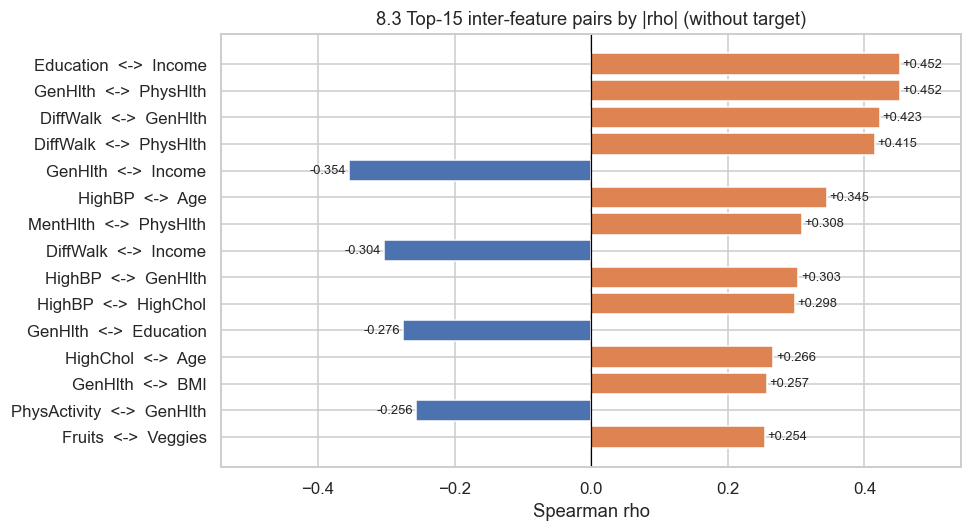

Top-15 inter-feature pairs (Spearman rho):
   Feature A Feature B       rho    |rho|
   Education    Income  0.451978 0.451978
     GenHlth  PhysHlth  0.451847 0.451847
    DiffWalk   GenHlth  0.422791 0.422791
    DiffWalk  PhysHlth  0.415022 0.415022
     GenHlth    Income -0.354253 0.354253
      HighBP       Age  0.344535 0.344535
    MentHlth  PhysHlth  0.308050 0.308050
    DiffWalk    Income -0.303711 0.303711
      HighBP   GenHlth  0.303300 0.303300
      HighBP  HighChol  0.298199 0.298199
     GenHlth Education -0.275783 0.275783
    HighChol       Age  0.266355 0.266355
     GenHlth       BMI  0.257342 0.257342
PhysActivity   GenHlth -0.256241 0.256241
      Fruits   Veggies  0.254342 0.254342


In [16]:
# --- 8.3 Top-15 inter-feature pairs (without target) ---
feature_corr = corr_df.drop("Diabetes_binary", axis=0).drop("Diabetes_binary", axis=1)

# Flatten the upper triangle (k=1 excludes the diagonal) into a sortable pair list
upper_idx = np.triu_indices_from(feature_corr.values, k=1)
pairs = pd.DataFrame({
    "Feature A": feature_corr.columns[upper_idx[0]],
    "Feature B": feature_corr.columns[upper_idx[1]],
    "rho":       feature_corr.values[upper_idx],
}).assign(**{"|rho|": lambda d: d["rho"].abs()}).sort_values("|rho|", ascending=False)

top_pairs = pairs.head(15)

# Horizontal bars coloured by sign, annotated with rho
fig, ax = plt.subplots(figsize=(9, 5))
pair_labels = [f"{a}  <->  {b}" for a, b in zip(top_pairs["Feature A"], top_pairs["Feature B"])]
colors = ["#DD8452" if r > 0 else "#4C72B0" for r in top_pairs["rho"]]
bars = ax.barh(pair_labels[::-1], top_pairs["rho"].values[::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, top_pairs["rho"].values[::-1]):
    xpos = val + (0.004 if val >= 0 else -0.004)
    ha = "left" if val >= 0 else "right"
    ax.text(xpos, bar.get_y() + bar.get_height() / 2, f"{val:+.3f}", va="center", ha=ha, fontsize=8.5)
ax.set_xlabel("Spearman rho")
ax.set_title("8.3 Top-15 inter-feature pairs by |rho| (without target)", fontsize=12)
lim = top_pairs["|rho|"].max() + 0.09
ax.set_xlim(-lim, lim)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "08_3_top15_pairs.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top-15 inter-feature pairs (Spearman rho):")
print(top_pairs[["Feature A", "Feature B", "rho", "|rho|"]].to_string(index=False))

**Interpretation:**

**No severe multicollinearity, but a moderate structural share.** The strongest inter-feature correlation is rho = 0.452 (Education <-> Income; GenHlth <-> PhysHlth) — well below the critical threshold of |rho| = 0.7 at which individual features become problematic for logistic regression. However, **eight of the fifteen pairs** fall in the range |rho| = 0.25-0.45, which can cumulatively lead to unstable coefficients. **A VIF check in Phase 3 is therefore recommended** before training the logistic-regression baseline. Tree-based models (gradient boosting, random forests) are unaffected by this structural share.

**Three structural clusters become visible:**

*Physical-health cluster* (4 of the top 7): GenHlth <-> PhysHlth (rho = 0.45), DiffWalk <-> GenHlth (rho = 0.42), DiffWalk <-> PhysHlth (rho = 0.42), MentHlth <-> PhysHlth (rho = 0.31). Four features measure physical and subjective health impairment from overlapping perspectives. Since these four are simultaneously among the strongest target correlates (see 8.2), this cluster is the **most important composite candidate**: a "physical-health score" from GenHlth, PhysHlth and DiffWalk would bundle the information and reduce multicollinearity in the LogReg.

*Socioeconomic cluster:* Education <-> Income (rho = 0.45), GenHlth <-> Income (rho = -0.35), DiffWalk <-> Income (rho = -0.30), GenHlth <-> Education (rho = -0.28). The strong tie between Education and Income is expected (educational attainment shapes income). Notable is the **negative spillover** onto health variables: higher education/income go together with better health — a social gradient well established in the epidemiological diabetes literature (Agardh et al., 2011). A socioeconomic composite (Income + Education) is examined in Phase 3.

*Cardiovascular cluster:* HighBP <-> Age (rho = 0.35), HighBP <-> HighChol (rho = 0.30), HighChol <-> Age (rho = 0.27), HighBP <-> GenHlth (rho = 0.30). High blood pressure, high cholesterol and age co-occur — biologically expected, since cardiovascular risk accumulates with age. HeartDiseaseorAttack and Stroke fall just outside the top 15 here, but their link was visible in 8.1 (rho = 0.20-0.21), so the cardiovascular composite (HighBP, HighChol, HeartDiseaseorAttack, Stroke) remains a justified candidate.

**Further findings:**

- **PhysActivity <-> GenHlth (rho = -0.26):** physically active respondents report better general health. PhysActivity thus carries some health-related signal indirectly (via GenHlth), even though its *direct* correlation with the target is weak and it does not appear in the 8.2 top list.
- **Fruits <-> Veggies (rho = 0.25):** the two diet features move together, as expected. Both correlate only weakly with the target but are suitable building blocks for a lifestyle composite.
- **MentHlth <-> PhysHlth (rho = 0.31):** mental and physical health are linked. Despite this, MentHlth itself correlates barely with diabetes (rho = 0.04, see 8.2), supporting the 8.1 reading that MentHlth is dampened by zero-inflation — hence it is *tested* as a hurdle encoding in Phase 3 (kept only if ablation supports it).

**Consequences for Phase 3:**
- **Composite candidate 1 - physical-health score:** GenHlth, PhysHlth, DiffWalk
- **Composite candidate 2 - cardiovascular score:** HighBP, HighChol, HeartDiseaseorAttack, Stroke
- **Composite candidate 3 - socioeconomic score:** Income + Education
- **Composite candidate 4 - lifestyle score** (optional): PhysActivity, Fruits, Veggies, with Smoker and HvyAlcoholConsump inverted
- **VIF check** before the LogReg baseline (recommended; VIF > 5 as the action limit)
- Composite validation via ablation in Phase 4: compare PR-AUC with vs. without each composite

## 9. Outlier Investigation

An outlier is a value far from the rest. We distinguish two types: data errors (BMI = 98 is biologically implausible, probably a data-entry error) and rare but real cases (BMI = 60 is possible, but rare). Both disturb models — data errors because they are garbage, real extreme values because they can distort statistics and regression coefficients.

In Phase 3, for each numeric feature a decision must be made: leave as-is, cap, drop or transform. This decision should not be made by gut feeling. We provide the quantitative basis here.

**Which features are relevant?**

Classic outlier analysis assumes an interval-scaled numeric variable. For the other feature types it is not applicable, or it means something different:

| Feature type | Outlier analysis? | Relevant diagnostic |
|---|---|---|
| Binary | no - only 0 or 1 | near-constancy (see 6.1) |
| Ordinal | no - bounded categories | skew / ceiling effects (see 6.2) |
| Count / continuous | yes - focus of this section | outlier inspection (BMI, MentHlth, PhysHlth) |

For this dataset three features are relevant: **BMI** (continuous), **MentHlth** and **PhysHlth** (count variables, days in the past month, 0-30).

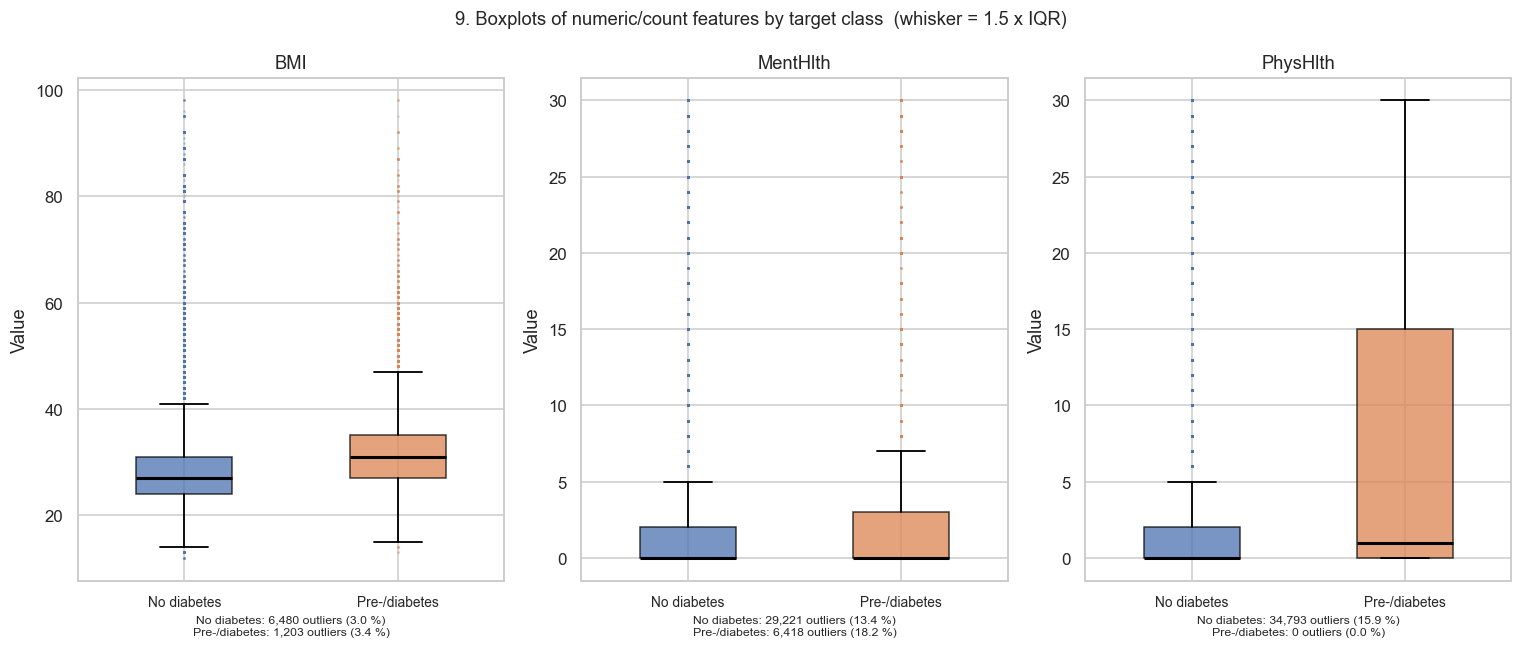

Feature       Class              Median      IQR   Whisker_up   Outliers       %
----------------------------------------------------------------------------
BMI           No diabetes          27.0      7.0         41.5      6,480   2.97%
BMI           Pre-/diabetes        31.0      8.0         47.0      1,203   3.40%
MentHlth      No diabetes           0.0      2.0          5.0     29,221  13.38%
MentHlth      Pre-/diabetes         0.0      3.0          7.5      6,418  18.16%
PhysHlth      No diabetes           0.0      2.0          5.0     34,793  15.94%
PhysHlth      Pre-/diabetes         1.0     15.0         37.5          0   0.00%


In [17]:
outlier_cols = NUMERIC_COLS + COUNT_COLS   # the three features where classic outlier analysis applies
palette      = {0: "#4C72B0", 1: "#DD8452"}
class_labels = {0: "No diabetes", 1: "Pre-/diabetes"}

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

for ax, col in zip(axes, outlier_cols):
    # split the feature's values by target class -> two boxes side by side
    data_by_class = [df.loc[df["Diabetes_binary"] == c, col].values for c in [0, 1]]

    bp = ax.boxplot(
        data_by_class,
        patch_artist=True,                                          # allow coloured boxes
        widths=0.45,
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker=".", markersize=1.8, alpha=0.2, linestyle="none"),
    )
    # colour each box and its outlier points by class (blue = no diabetes, orange = pre-/diabetes)
    for patch, cls in zip(bp["boxes"], [0, 1]):
        patch.set_facecolor(palette[cls])
        patch.set_alpha(0.75)
    for flier, cls in zip(bp["fliers"], [0, 1]):
        flier.set_markerfacecolor(palette[cls])
        flier.set_markeredgecolor(palette[cls])

    ax.set_xticks([1, 2])
    ax.set_xticklabels([class_labels[0], class_labels[1]], fontsize=9)
    ax.set_title(col, fontsize=12)
    ax.set_ylabel("Value")

    # count IQR-rule outliers per class (1.5 x IQR beyond Q1/Q3) and show them under the axis
    lines = []
    for cls, dat in zip([0, 1], data_by_class):
        q1, q3 = np.percentile(dat, [25, 75])
        iqr = q3 - q1
        n_out = ((dat > q3 + 1.5 * iqr) | (dat < q1 - 1.5 * iqr)).sum()
        lines.append(f"{class_labels[cls]}: {n_out:,} outliers ({n_out/len(dat)*100:.1f} %)")
    ax.set_xlabel("\n".join(lines), fontsize=8)

plt.suptitle("9. Boxplots of numeric/count features by target class  (whisker = 1.5 x IQR)", fontsize=12)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "09_outlier_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

# Numeric backup of the plot: per-class median, IQR, upper whisker, and IQR-rule outlier count
print(f"{'Feature':<12}  {'Class':<16}  {'Median':>7}  {'IQR':>7}  {'Whisker_up':>11}  {'Outliers':>9}  {'%':>6}")
print("-" * 76)
for col in outlier_cols:
    for cls in [0, 1]:
        dat = df.loc[df["Diabetes_binary"] == cls, col].values
        q1, q3 = np.percentile(dat, [25, 75])
        iqr = q3 - q1
        upper = q3 + 1.5 * iqr                                       # upper whisker / outlier threshold
        n_out = ((dat > upper) | (dat < q1 - 1.5 * iqr)).sum()
        print(f"{col:<12}  {class_labels[cls]:<16}  {np.median(dat):>7.1f}  {iqr:>7.1f}  "
              f"{upper:>11.1f}  {n_out:>9,}  {n_out/len(dat)*100:>5.2f}%")

**Interpretation:**

**BMI - moderate class shift, similar outlier rates.** The median shifts from 27 (no diabetes) to 31 (pre-/diabetes), the IQR stays nearly identical (7 vs. 8). The outlier rates are comparable in both classes (3.0 % vs. 3.4 %). This means BMI extreme values are **not class-discriminating** but general noise or recording errors — they spread proportionally across both classes. Consequence for Phase 3: a single capping (e.g. P1/P99) loses no class-specific information and is methodologically safe. The exact threshold is justified in 9.2 and re-derived on the training split in NB03.

**MentHlth - the IQR method collapses on zero-inflation.** Both classes have median 0 and small IQRs (2 and 3). The whiskers lie at 5 and 7.5, and everything above is mechanically flagged as an outlier — 13.4 % and 18.2 % of the data respectively. These values are **not real outliers** but a mathematical consequence of zero-inflation (69 % zeros). When the box collapses to 0, even a moderate value (6 or 8 bad days a month) is classified as "extreme", though it is perfectly plausible. This is exactly the failure pattern we expected methodologically.

The distribution also shows a slight class shift (somewhat more positive values and a slightly larger IQR in the diabetes group), which is, however, dampened by the zero-inflation. Phase 3 will therefore *test* a hurdle encoding for MentHlth to separate this dampened effect (kept only if ablation supports it).

**PhysHlth - the key finding: outliers are class-relative.** This is the most striking result of this section. In the control group the distribution is practically identical to MentHlth: median 0, IQR 2, 15.9 % "outliers". In the diabetes group the picture changes completely:

- the median shifts to 1
- **the IQR explodes to 15** (Q1 = 0, Q3 = 15)
- the whisker reaches 37.5 — above the maximum of 30
- consequence: **0 IQR outliers**, even though values up to 30 occur

This means: the same values (e.g. 12 days of poor physical health) are outliers in the control group but **typical within-box values** in the diabetes group. Classic outlier removal would here systematically destroy the very signal that discriminates diabetes status.

This is a strong argument against any form of outlier removal for the count features — and at the same time the clearest motivation for a hurdle encoding in Phase 3 that separates the binary component (any bad days yes/no) from the continuous component (how many).

**Consequences for Phase 3:**

- **BMI:** capping methodologically justifiable; concrete threshold fixed in 9.2 (and re-derived on train)
- **MentHlth & PhysHlth:** no outlier removal; instead a hurdle encoding is *tested* (`_any`: 0/1 - were there any bad days; `_days`: number if > 0), kept only if ablation supports it (Phase 4)
- The class-relative nature of outliers in PhysHlth is a finding worth reporting on its own in the thesis discussion (diabetes status is linked to a fundamentally different PhysHlth distribution, not just a mean shift)

### 9.2 BMI - comparison of classic outlier definitions

From 9.1 we know: BMI is the only numeric feature for which classic outlier methods are substantively applicable. Which of the three standard methods we use in Phase 3 depends on how well it fits the distribution shape. BMI is right-skewed (median 27, maximum 98) — methods with a symmetry or normality assumption are systematically problematic.

We compare three methods on the same distribution:

- **IQR (Tukey, 1977):** bounds at Q1 - 1.5*IQR and Q3 + 1.5*IQR. Symmetric around the box, but asymmetric in effect for right-skewed data.
- **3-sigma:** bounds at mu +/- 3*sigma. Assumes normality; for right-skewed data also self-referential — the outliers themselves inflate sigma and thereby partly mask themselves.
- **Percentile (P1/P99):** distribution-free, robust to skew and extreme values; the threshold is a convention, not a model result.

The left panel shows the BMI boxplot with all three upper thresholds drawn in. The right table quantifies how many values each method flags as outliers. The view is clipped at P99.8 so the thresholds stay visible; the extreme BMI values (> 75) are still present in the data.

*(As in §1.2: the threshold chosen here is the basis for Phase 3, but the actual capping bounds are recomputed on the training split in NB03 — not taken from this full-data view.)*

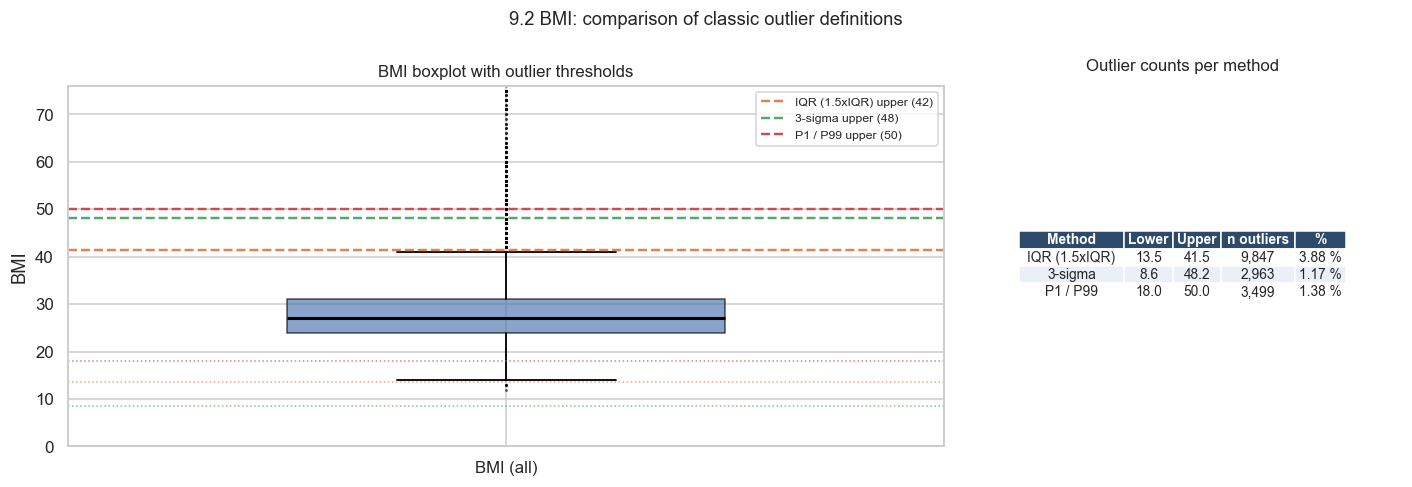

In [18]:
bmi = df["BMI"].values
n   = len(bmi)

# --- Compute the three outlier thresholds ---
q1, q3    = np.percentile(bmi, [25, 75])
iqr       = q3 - q1
mu, sigma = bmi.mean(), bmi.std()
p1, p99   = np.percentile(bmi, [1, 99])

# (lower, upper) bound per method
methods = {
    "IQR (1.5xIQR)": (q1 - 1.5 * iqr, q3 + 1.5 * iqr),
    "3-sigma":       (mu - 3 * sigma,  mu + 3 * sigma),
    "P1 / P99":      (p1,              p99),
}
colors_line = {"IQR (1.5xIQR)": "#DD8452", "3-sigma": "#55A868", "P1 / P99": "#C44E52"}

fig, (ax_box, ax_tab) = plt.subplots(
    1, 2, figsize=(13, 4.5),
    gridspec_kw={"width_ratios": [2, 1]},
)

# --- Left: BMI boxplot with each method's upper threshold drawn in ---
bp = ax_box.boxplot(
    bmi,
    vert=True,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker=".", markersize=1.5, alpha=0.15, color="#4C72B0"),
)
bp["boxes"][0].set_facecolor("#4C72B0")
bp["boxes"][0].set_alpha(0.65)

y_max = np.percentile(bmi, 99.8)   # clip the view so the threshold lines stay visible
ax_box.set_ylim(0, y_max + 3)

for name, (lo, hi) in methods.items():
    col = colors_line[name]
    ax_box.axhline(hi, color=col, linewidth=1.6, linestyle="--", label=f"{name} upper ({hi:.0f})")
    if lo > 0:                                   # only draw a lower line if it is above 0
        ax_box.axhline(lo, color=col, linewidth=1.0, linestyle=":", alpha=0.7)

ax_box.set_xticks([1])
ax_box.set_xticklabels(["BMI (all)"])
ax_box.set_ylabel("BMI")
ax_box.set_title("BMI boxplot with outlier thresholds", fontsize=11)
ax_box.legend(fontsize=8, loc="upper right")

# --- Right: table of how many values each method flags as outliers ---
rows, col_labels = [], ["Method", "Lower", "Upper", "n outliers", "%"]
for name, (lo, hi) in methods.items():
    n_out = ((bmi > hi) | (bmi < lo)).sum()
    rows.append([name, f"{lo:.1f}", f"{hi:.1f}", f"{n_out:,}", f"{n_out/n*100:.2f} %"])

ax_tab.axis("off")
tbl = ax_tab.table(cellText=rows, colLabels=col_labels, cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width(list(range(len(col_labels))))
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2d4a6b")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#eaf0f8")
    cell.set_edgecolor("white")

ax_tab.set_title("Outlier counts per method", fontsize=11, pad=10)

plt.suptitle("9.2 BMI: comparison of classic outlier definitions", fontsize=12)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "09_2_bmi_outlier_methods.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

The three methods give markedly different results — from 1.17 % to 3.88 % flagged outliers. This shows that the choice of method is not a formality but substantially affects which data points are treated in Phase 3.

**IQR (3.88 %, 9,847 outliers) - too aggressive for right-skewed data.** The upper IQR bound is 41.5 — barely above the class-III-obesity threshold of BMI 40 (WHO), so it flags almost the entire severe-obesity range (~42-50) as outliers. Those values are biologically real and present with substantial frequency in the US adult population; classifying them as "outliers" is methodologically questionable. The finding confirms the theoretical expectation: IQR is symmetric around the box, but for right-skewed data a sensible outlier definition must be asymmetric. **Rejected.**

**3-sigma (1.17 %, 2,963 outliers) - distorted by the distribution assumption and self-reference.** The upper 3-sigma bound is 48.2, higher than the IQR bound. This seems more appropriate at first but has two problems. First, 3-sigma assumes normality — violated for visibly skewed data. Second, mu and sigma are themselves pulled by extreme values: BMI = 98 raises sigma and thus the outlier threshold. The few outliers are therefore not a sign of clean data but of a method that partly hides its own outliers. The lower bound (8.6) lies below the physiological minimum (BMI ~12 is extremely low but documented) and flags no values in this distribution. **Rejected.**

**P1 / P99 (1.38 %, 3,499 outliers) - the methodologically cleanest choice.** The percentile method gives bounds at 18 and 50. These values are computed independently of skew and distribution shape and happen to coincide with established clinical BMI categories: BMI < 18.5 = underweight (WHO), BMI >= 50 = super-obesity. By construction it targets the lowest and highest ~1 % of values — a deliberate, documentable convention rather than an implicit distribution assumption.

**Decision for Phase 3.** Capping at BMI in [18, 50] via the percentile method (P1/P99). Methodological justification:

1. Distribution-free — no assumption about skew or normality
2. Robustness — percentiles are not themselves pulled by extreme values
3. Clinical plausibility — the resulting bounds correspond to WHO thresholds
4. Conservative aggressiveness — 1.38 % capping loses minimal information but removes documented implausibilities (BMI = 98)

The operation in Phase 3 is a **winsorizing**: values < 18 are set to 18, values > 50 to 50. No rows are removed — the information "extreme BMI" is preserved through the capping value without destabilising models via single values. The exact bounds (P1/P99) are recomputed on the training split in NB03, so no full-data quantity enters the fitted pipeline.

## 10. Summary and Consequences for Data Preparation

The data-understanding phase shows that the dataset is technically clean: there are no missing values, all variables are consistently coded, and the target is binary.

At the same time, the exploratory analysis yields several methodologically relevant points to be systematically checked and implemented in the next phase.

The target is strongly imbalanced: only ~13.9 % of observations belong to the positive class. Accuracy should therefore not be used as the primary metric. Instead, the following modelling phases assess how well the models perform with respect to PR-AUC and recall of the positive class in particular.

Exact duplicates are not deleted — they are expected in a coarsely coded survey and do not by themselves indicate data errors. They do, however, create a leakage risk: identical feature vectors split across train and test would let a model effectively memorise test rows and inflate the estimated performance. NB03 therefore uses a group-aware split (Section 5) that keeps identical vectors on the same side of the split, rather than removing them. Feature vectors with *conflicting* labels additionally point to empirical label noise; this is taken into account when interpreting model performance later, especially since the target measures *diagnosed* diabetes status rather than actual disease status.

The exploratory analyses show that GenHlth, HighBP, BMI, DiffWalk and HighChol are most strongly associated with the target. These variables are therefore watched especially in the following phases — e.g. in feature importance, permutation importance or SHAP analyses.

The correlation analysis shows no severe multicollinearity but several substantively plausible feature clusters, in particular cardiovascular health, physical health and socioeconomic status. NB03 therefore tests whether sensible composite features can be built from these clusters. Whether these features actually remain in the final model is decided empirically later via model comparison and ablation.

For BMI, the outlier analysis shows that extreme values are present. NB03 therefore tests a capping / winsorizing based on the bounds determined here (recomputed on the training split). No rows are removed; only extreme BMI values are bounded.

MentHlth and PhysHlth are not treated as classic outliers, since high values can carry substantively relevant information. NB03 therefore tests a hurdle encoding that separately models whether any bad health days were reported and how many.

This yields the following work steps for NB03: train/test split (group-aware, given the exact-duplicate share from Section 5), BMI capping, hurdle encoding for MentHlth and PhysHlth, construction and later validation of possible composite features, a VIF check for the logistic-regression baseline, and the build of suitable preprocessing pipelines — all fitted train-only / per CV-fold.